# Exploring AAPL Stock Data with Pandas and Matplotlib

In this assignment, you will use `AAPL.csv` to practice basic data inspection, summary statistics, and plotting with Pandas and Matplotlib.

The dataset contains daily Apple stock price data with the columns `date`, `adj_close`, `close`, `high`, `low`, `open`, `volume`, and `symbol`.

For each exercise, write your code between the `# <START>` and `# <END>` comments. 


In [1]:
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')


## Exercise 1: Load and Inspect the Dataset

Read `AAPL.csv` into a DataFrame named `df`. Then display:

- The first 10 rows
- The shape of the dataset
- The column names
- The data types of each column


In [2]:
# <START>
# Read AAPL.csv into df
df = pd.read_csv('AAPL.csv')

# Display the first 10 rows
display(df[:11])

# Display the shape, columns, and data types
display(df.shape,df.columns,df.dtypes)

# <END>


,date,adj_close,close,high,low,open,volume,symbol
0,2015-01-02,24.192606,27.332500,27.860001,26.837500,27.847500,212818400,AAPL
1,2015-01-05,23.511055,26.562500,27.162500,26.352501,27.072500,257142000,AAPL
2,2015-01-06,23.513268,26.565001,26.857500,26.157499,26.635000,263188400,AAPL
3,2015-01-07,23.842981,26.937500,27.049999,26.674999,26.799999,160423600,AAPL
4,2015-01-08,24.759077,27.972500,28.037500,27.174999,27.307501,237458000,AAPL
5,2015-01-09,24.785631,28.002501,28.312500,27.552500,28.167500,214798000,AAPL
6,2015-01-12,24.174902,27.312500,28.157499,27.200001,28.150000,198603200,AAPL
7,2015-01-13,24.389544,27.555000,28.200001,27.227501,27.857500,268367600,AAPL
8,2015-01-14,24.296606,27.450001,27.622499,27.125000,27.260000,195826400,AAPL
9,2015-01-15,23.637186,26.705000,27.514999,26.665001,27.500000,240056000,AAPL


(2858, 8)

Index(['date', 'adj_close', 'close', 'high', 'low', 'open', 'volume',
       'symbol'],
      dtype='str')

date             str
adj_close    float64
close        float64
high         float64
low          float64
open         float64
volume         int64
symbol           str
dtype: object

## Exercise 2: Convert and Sort Dates

The `date` column is currently read as text. Convert it to a datetime column, sort the rows by date, and reset the index.

After sorting, display the earliest date and latest date in the dataset.


In [3]:
# <START>
# Convert date column to datetime
df["date"] = pd.to_datetime(df["date"])

# Sort by date and reset the index
df = df.sort_values("date",ignore_index=True)
# Display the first and last dates
display(df.head(1))
display(df.tail(1))


# <END>


,date,adj_close,close,high,low,open,volume,symbol
0,2015-01-02,24.192606,27.3325,27.860001,26.8375,27.8475,212818400,AAPL


,date,adj_close,close,high,low,open,volume,symbol
2857,2026-05-14,298.209991,298.209991,300.350006,295.380005,299.820007,33673067,AAPL


## Exercise 3: Summary Statistics

Find the mean, standard deviation, highest value, and lowest value for these numerical columns:

- `open`
- `high`
- `low`
- `close`
- `adj_close`
- `volume`

Store the result in a variable named `summary_stats` and display it.


In [4]:
numeric_cols = ['open', 'high', 'low', 'close', 'adj_close', 'volume']

# <START>
# Calculate mean, standard deviation, minimum, and maximum
header = ['mean', 'standard deviation','minimum','maximum']
summary_stats = pd.DataFrame(columns=header,index=numeric_cols)
for i in numeric_cols:
    summary_stats.loc[i,'mean'] = df.loc[:, i].mean()
    summary_stats.loc[i,'standard deviation'] = df.loc[:,i].std()
    summary_stats.loc[i,'minimum'] = df.loc[:,i].min()
    summary_stats.loc[i,'maximum'] = df.loc[:,i].max()

# Display summary_stats
display(summary_stats)
# <END>


,mean,standard deviation,minimum,maximum
open,113.560275,77.639929,22.5,299.820007
high,114.790064,78.469748,22.9175,300.920013
low,112.42256,76.889401,22.3675,295.380005
close,113.659821,77.7177,22.584999,298.869995
adj_close,111.213828,78.157844,20.56587,298.869995
volume,109332968.707838,67944437.007035,17910600,648825200


## Exercise 4: Highest and Lowest Adjusted Close

Find the row where Apple had the highest `adj_close` price and the row where it had the lowest `adj_close` price.

Display the `date`, `adj_close`, and `volume` for both rows.


In [5]:
# <START>
# Find the index of the highest and lowest adjusted close values
high = df.loc[:,'adj_close'].idxmax()
low = df.loc[:,'adj_close'].idxmin()
print(high,low)

# Select date, adj_close, and volume for both rows


print('Highest adjusted close:')
display(df.loc[[high],['date','adj_close','volume']])

print('Lowest adjusted close:')
display(df.loc[[low],['date','adj_close','volume']])

# <END>


2856 342
Highest adjusted close:


,date,adj_close,volume
2856,2026-05-13,298.869995,52684300


Lowest adjusted close:


,date,adj_close,volume
342,2016-05-12,20.56587,305258800


## Exercise 5: Plot Date vs Adjusted Close

Create a line plot showing how `adj_close` changes over time.

Your plot should include:

- Figure size `(12, 5)`
- A blue line
- Title: `AAPL Adjusted Close Price Over Time`
- X-axis label: `Date`
- Y-axis label: `Adjusted Close Price`


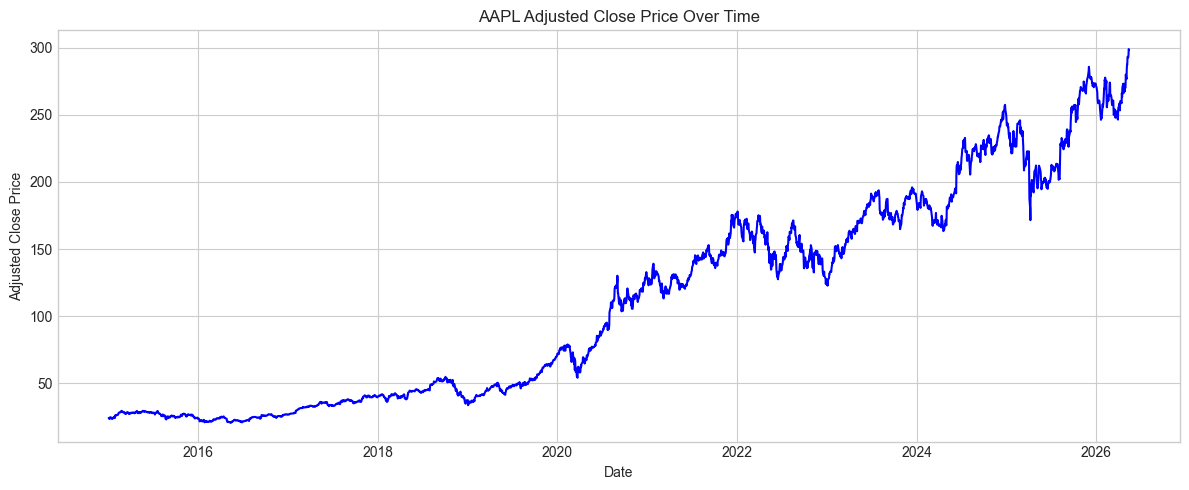

In [6]:
# <START>
f = plt.figure()
f.set_figwidth(12)
f.set_figheight(5)
plt.plot(df['date'],df.loc[:,'adj_close'],color = 'b')
plt.title("AAPL Adjusted Close Price Over Time")
plt.xlabel("Date")
plt.ylabel("Adjusted Close Price")
plt.tight_layout()
plt.show()
# <END>


## Exercise 6: Plot Trading Volume Over Time

Create a line plot for `volume` over time.

Your plot should include:

- Figure size `(12, 5)`
- A purple line
- Title: `AAPL Trading Volume Over Time`
- X-axis label: `Date`
- Y-axis label: `Volume`


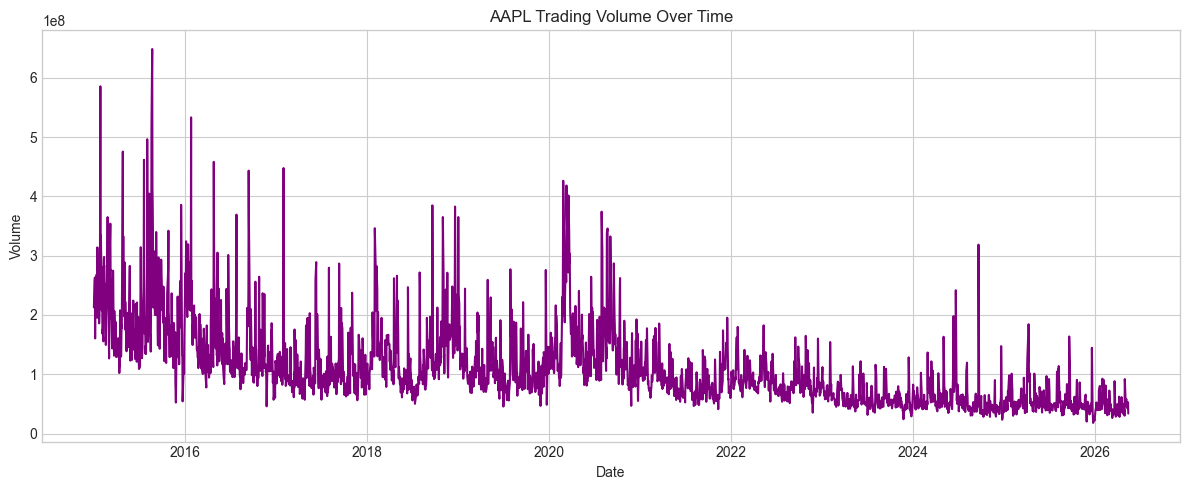

In [7]:
# <START>
f2 = plt.figure()
f2.set_figwidth(12)
f2.set_figheight(5)
plt.plot(df['date'],df.loc[:,'volume'],color = 'purple')
plt.title("AAPL Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.tight_layout()
plt.show()
# <END>


## Exercise 7: Top 10 Highest Volume Days

Find the 10 days with the highest trading volume and store them in `top_volume_days`.

Then create a bar chart with:

- `date` on the X-axis
- `volume` on the Y-axis
- Title: `Top 10 AAPL Trading Volume Days`
- Rotated X-axis labels so the dates are readable


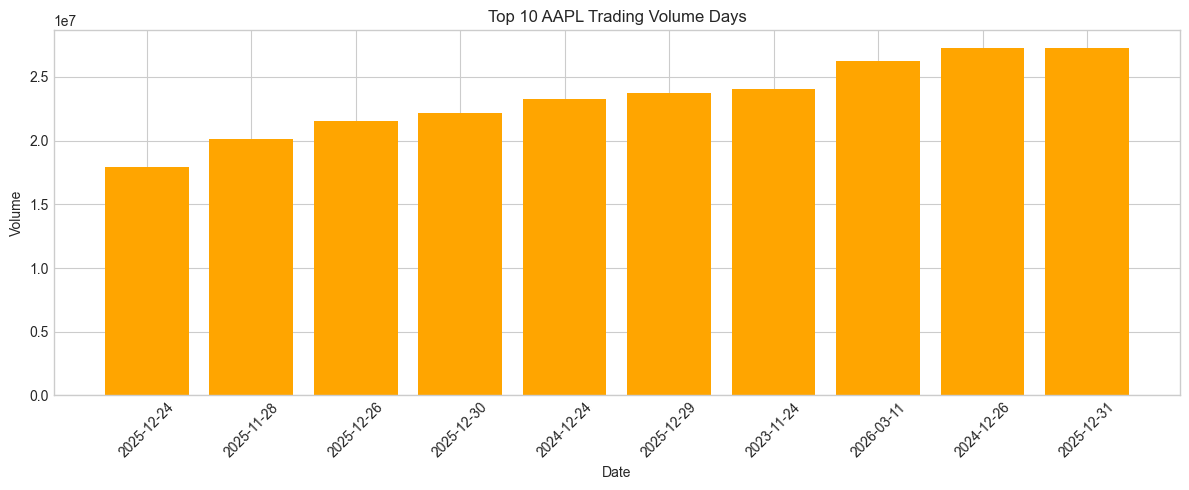

In [8]:
# <START>
# Find the 10 highest volume days
top_volume_days = df.sort_values('volume',ignore_index=True).head(10)
# Plot the result
plt.figure(figsize=(12, 5))
plt.bar(top_volume_days['date'].dt.strftime("%Y-%m-%d"), top_volume_days['volume'], color='orange')
plt.title('Top 10 AAPL Trading Volume Days')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.xticks(rotation=45, ha='center')
plt.tight_layout()
plt.show()
# <END>


## Exercise 8: Moving Average Plot

Create two new columns:

- `ma_20`: 20-day moving average of `adj_close`
- `ma_50`: 50-day moving average of `adj_close`

Then plot `adj_close`, `ma_20`, and `ma_50` on the same graph.


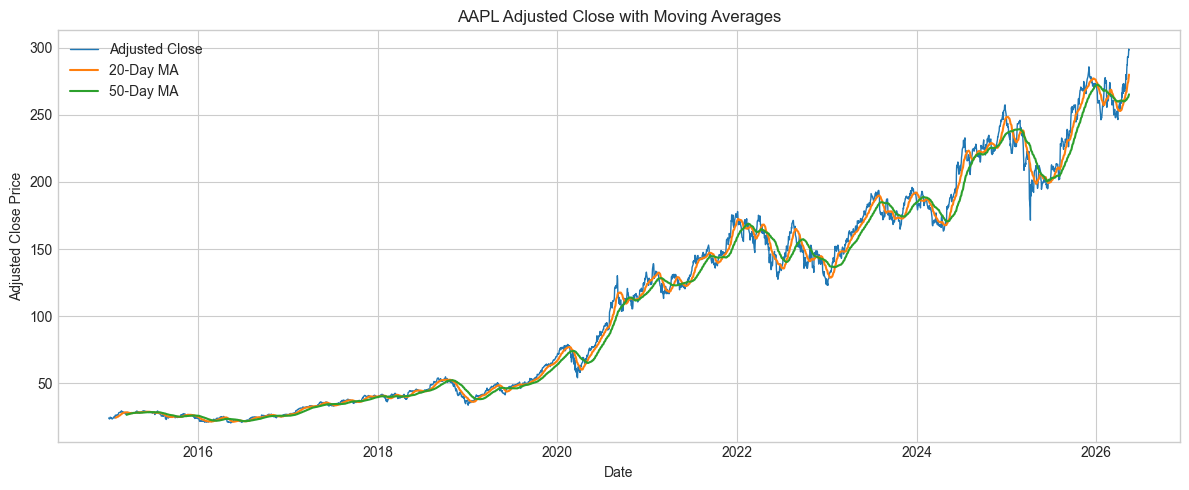

In [9]:
# <START>
# Calculate moving averages
df['ma_20'] = df['adj_close'].rolling(window=20).mean()
df['ma_50'] = df['adj_close'].rolling(window=50).mean()

# Plot adjusted close and moving averages
plt.figure(figsize=(12, 5))
plt.plot(df['date'], df['adj_close'], label='Adjusted Close', linewidth=1)
plt.plot(df['date'], df['ma_20'], label='20-Day MA', linewidth=1.5)
plt.plot(df['date'], df['ma_50'], label='50-Day MA', linewidth=1.5)
plt.title('AAPL Adjusted Close with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Adjusted Close Price')
plt.legend()
plt.tight_layout()
plt.show()
# <END>


## Exercise 9: Relationship Between Daily Range and Volume

Create a new column named `daily_range` using:

`daily_range = high - low`

Then make a scatter plot with `daily_range` on the X-axis and `volume` on the Y-axis.


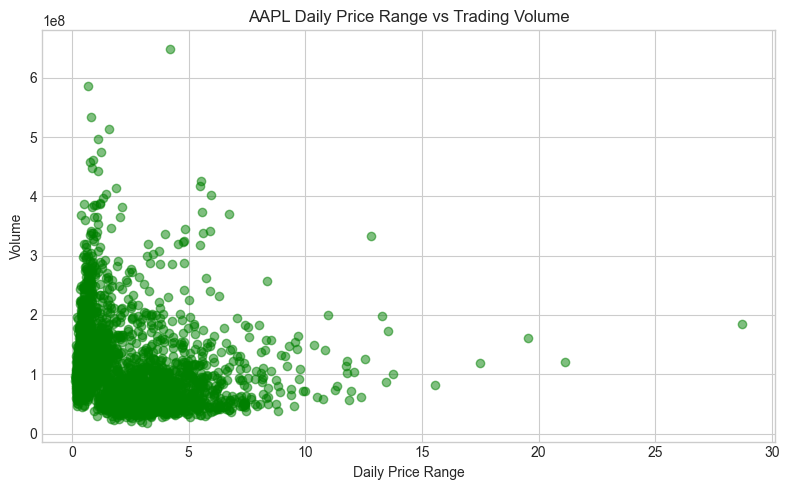

In [10]:
# <START>
# Calculate daily range
df['daily_range'] = df['high'] - df['low']
# Create scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(df['daily_range'], df['volume'], alpha=0.5, color='green')
plt.title('AAPL Daily Price Range vs Trading Volume')
plt.xlabel('Daily Price Range')
plt.ylabel('Volume')
plt.tight_layout()
plt.show()
# <END>


## Bonus Exercise: Monthly Average Adjusted Close

Group the data by month and calculate the average `adj_close` for each month. Plot the monthly averages as a line plot.

Hint: Use `df.set_index('date').resample('ME')`.


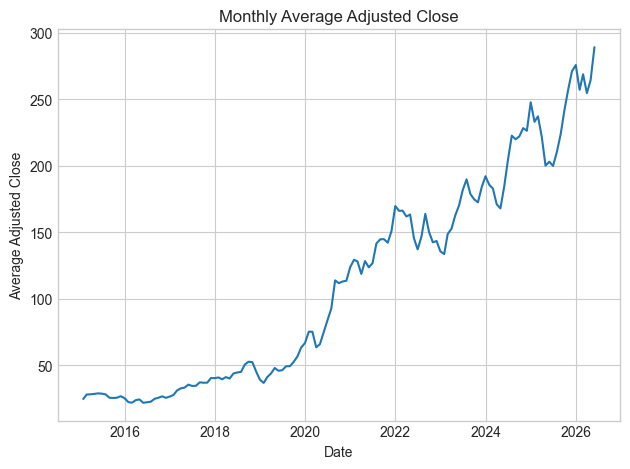

In [11]:
# <START>
# Calculate monthly average adjusted close
r = df.set_index('date').resample('ME')
monthly_average = pd.DataFrame([(month_end,group['adj_close'].mean()) for month_end,group in r],columns=['month_end','monthly_average'])
monthly_average["month_end"] = pd.to_datetime(monthly_average['month_end'])
# Plot monthly average adjusted close
plt.plot(monthly_average['month_end'],monthly_average['monthly_average'])
plt.title("Monthly Average Adjusted Close")
plt.xlabel("Date")
plt.ylabel("Average Adjusted Close")
plt.tight_layout()
plt.show()

# <END>
